In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.cm as cm
from scipy.sparse.linalg import eigs
from scipy.sparse.linalg import eigsh
from scipy.sparse import diags
from scipy.linalg import eig  
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import collections

In [27]:
G = nx.Graph()
with open("../data/EU_air//EUAirTransportation_multiplex.edges", "r") as f:
    for line in f:
        parts = line.strip().split()
        # Use the first two columns as nodes, last column as weight
        node1, node2, weight = parts[1], parts[2], float(parts[3])
        G.add_edge(node1, node2, weight=weight)

node_pos = {}
with open("../data/EU_air//EUAirTransportation_nodes.txt", "r") as f:
    next(f)  # Skip header line
    for line in f:
        parts = line.strip().split()
        node_id = parts[0]
        lon = float(parts[-2])
        lat = float(parts[-1])
        node_pos[node_id] = (lon, lat)

num_nodes = G.number_of_nodes()
print(f"Number of nodes: {num_nodes}")
num_edges = G.number_of_edges()
print(f"Number of edges: {num_edges}")




Number of nodes: 417
Number of edges: 2953


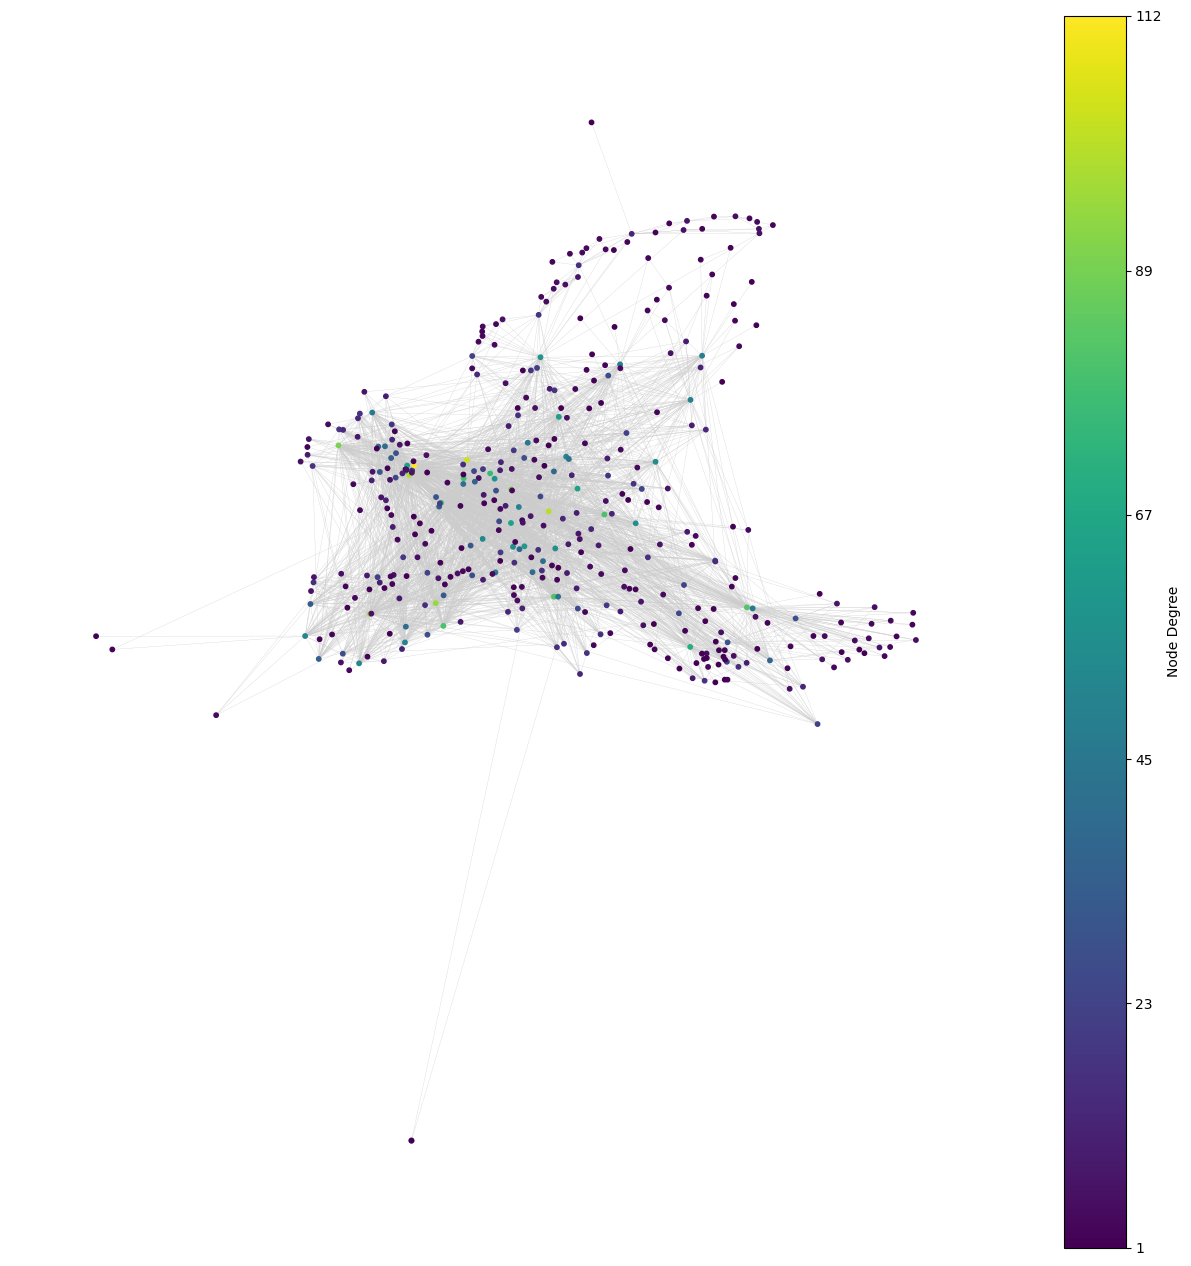

In [3]:
# Visualization with node colors based on degree

fig, ax = plt.subplots(figsize=(16, 16))
degrees = np.array([G.degree(n) for n in G.nodes()])
colors = degrees
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=degrees.min(), vmax=degrees.max())
nodes = nx.draw_networkx(
    G,
    pos=node_pos,
    with_labels=False,
    node_size=10,
    node_color=colors,
    cmap=cmap,
    edge_color='#cccccc',
    width=0.2,
    ax=ax
)
ax.axis('off')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='Node Degree', orientation='vertical')
cbar.set_ticks(np.linspace(degrees.min(), degrees.max(), num=6, dtype=int))
plt.show()


C:\Users\anant\AppData\Local\Temp\ipykernel_1712\1891134142.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(layers))


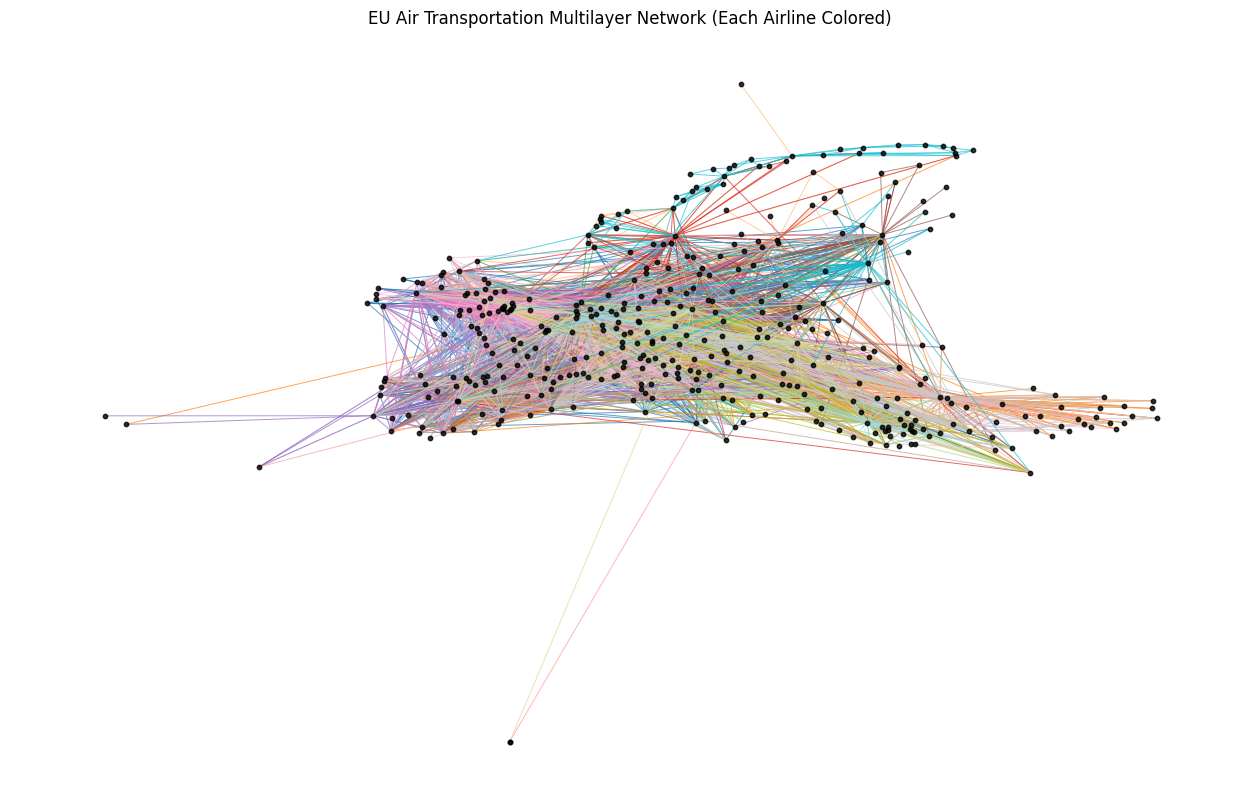

In [4]:
layer_edges = {}
with open("../data/EU_air//EUAirTransportation_multiplex.edges", "r") as f:
    for line in f:
        parts = line.strip().split()
        layer = parts[0]
        node1, node2 = parts[1], parts[2]
        layer_edges.setdefault(layer, []).append((node1, node2))

layers = sorted(layer_edges.keys(), key=int)
colors = cm.get_cmap('tab20', len(layers))

fig, ax = plt.subplots(figsize=(16, 10))

for i, layer in enumerate(layers):
    H = nx.Graph()
    H.add_edges_from(layer_edges[layer])
    
    nx.draw_networkx_edges(
        H,
        pos=node_pos,
        edge_color=[colors(i)],
        width=0.7,
        alpha=0.7,
        ax=ax
    )

nx.draw_networkx_nodes(
    G,
    pos=node_pos,
    node_size=10,
    node_color='black',
    alpha=0.8,
    ax=ax
)

ax.axis('off')
plt.title("EU Air Transportation Multilayer Network (Each Airline Colored)")
plt.show()


In [5]:
def plot_communities(G, community_of, node_pos=None, title="Communities on graph",
                     show_labels=False, edge_alpha=0.15, node_size=18):
    """
    Plot G with nodes colored by community_of[node].
    """

    nodes = list(G.nodes())

    if node_pos is None:
        pos = nx.spring_layout(G, seed=42)
    else:
        pos = node_pos

    nodes_with_pos = [u for u in nodes if u in pos]
    if not nodes_with_pos:
        raise ValueError("No nodes have positions. Provide a valid node_pos.")

    labels = np.array([community_of.get(u, -1) for u in nodes_with_pos])  # -1 for unknown
    known_mask = labels >= 0
    unknown_mask = ~known_mask

    unique_comms = sorted(np.unique(labels[known_mask]))
    comm_to_idx = {c: i for i, c in enumerate(unique_comms)}
    mapped = np.array([comm_to_idx[c] if c in comm_to_idx else -1 for c in labels])

    bright_colors = [
        "#e41a1c", 
        "#377eb8",  
        "#4daf4a",  
        "#984ea3",  
        "#ff7f00",  
        "#ffff33",  
        "#0a0a0a", 
    ]
    cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback
    color_list = bright_colors if len(unique_comms) <= len(bright_colors) else cmap.colors

    plt.figure(figsize=(10, 8))

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v) for u, v in G.edges() if u in pos and v in pos],
        width=0.4,
        alpha=edge_alpha,
        edge_color="gray",
    )

    xs = [pos[u][0] for u in nodes_with_pos]
    ys = [pos[u][1] for u in nodes_with_pos]

    if known_mask.any():
        plt.scatter(
            np.array(xs)[known_mask],
            np.array(ys)[known_mask],
            c=[color_list[i % len(color_list)] for i in mapped[known_mask]],
            s=node_size,
            alpha=0.95,
        )

    if unknown_mask.any():
        plt.scatter(
            np.array(xs)[unknown_mask],
            np.array(ys)[unknown_mask],
            c="lightgray",
            s=node_size,
            alpha=0.9,
            label="unlabeled",
        )

    if show_labels:
        for u in nodes_with_pos:
            x, y = pos[u]
            plt.text(x, y, str(u), fontsize=6, ha="center", va="center")

    handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=6,
               label=f"c={c}", markerfacecolor=color_list[i % len(color_list)],
               markeredgecolor="none")
        for i, c in enumerate(unique_comms)
    ]
    if unknown_mask.any():
        handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=6,
                              label="unlabeled", markerfacecolor="lightgray",
                              markeredgecolor="none"))
    if handles:
        plt.legend(handles=handles, title="Communities", loc="best", frameon=True)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()



C:\Users\anant\AppData\Local\Temp\ipykernel_1712\1548571776.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


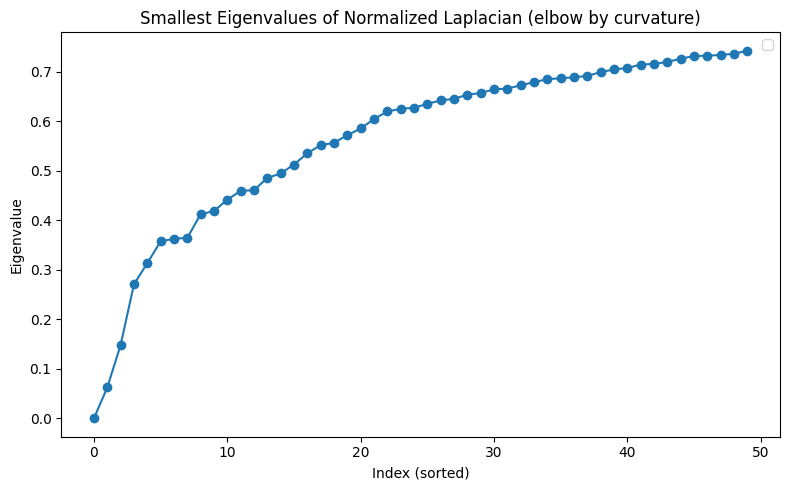

In [6]:
nodes = list(G.nodes())

Lnorm = nx.normalized_laplacian_matrix(G, nodelist=nodes).astype(np.float64)
num_cc = nx.number_connected_components(G)
eigvals, eigvecs = eigsh(Lnorm, k=50, which='SM')   
perm = np.argsort(eigvals)
eigvals = eigvals[perm]
eigvecs = eigvecs[:, perm]

plt.figure(figsize=(8, 5))
plt.plot(range(len(eigvals)), eigvals, marker='o', linestyle='-')

plt.title('Smallest Eigenvalues of Normalized Laplacian (elbow by curvature)')
plt.xlabel('Index (sorted)')
plt.ylabel('Eigenvalue')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:

def pick_k_by_curvature(eigvals, num_cc, return_debug=False):
    """
    Pick K using the curvature (second difference) elbow on the ascending spectrum.
    eigvals : ascending eigenvalues (1D array)
    num_cc  : number of connected components (zeros block size)

    Returns:
      K  (int), and optionally a debug dict.
    """
    lam = np.asarray(eigvals, dtype=float)
    n = lam.size
    start = int(num_cc)

    tail = lam[start:]
    if tail.size < 3:
        gaps = np.diff(tail)
        K = start + (np.argmax(gaps) + 1 if gaps.size else 1)
        if return_debug:
            return int(K), {"start": start, "method": "fallback_gap", "gaps": gaps}
        return int(K)

    second_diff = tail[2:] - 2*tail[1:-1] + tail[:-2]
    elbow_in_tail = int(np.argmax(second_diff)) + 1 
    K = start + elbow_in_tail

    if return_debug:
        return int(K), {
            "start": start,
            "second_diff": second_diff,
            "elbow_in_tail": elbow_in_tail,
            "K": int(K),
        }
    return int(K)


In [8]:
K, dbg = pick_k_by_curvature(eigvals, num_cc, return_debug=True)
print("Chosen K (curvature elbow):", K)


Chosen K (curvature elbow): 7


C:\Users\anant\AppData\Local\Temp\ipykernel_1712\2510024013.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


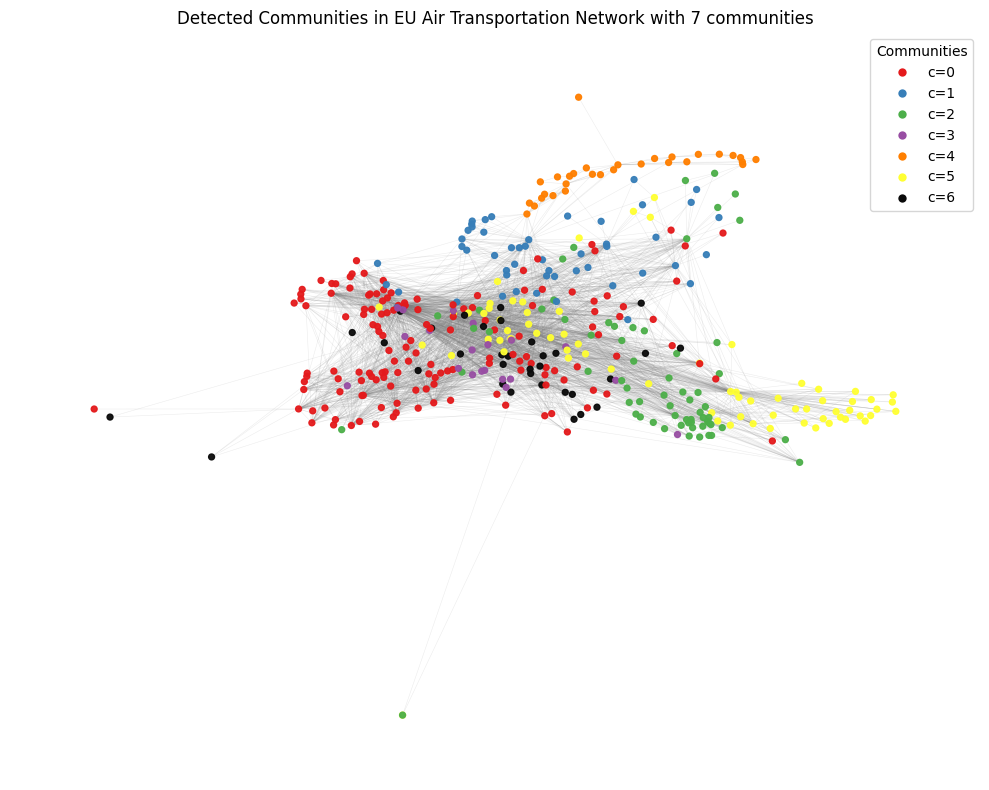

In [9]:
U = eigvecs[:, num_cc:num_cc + K]

row_norms = np.linalg.norm(U, axis=1, keepdims=True)
row_norms[row_norms == 0.0] = 1.0
U_norm = U / row_norms

km = KMeans(n_clusters=K, n_init=20, random_state=0)
labels = km.fit_predict(U_norm)
community_of = {nodes[i]: int(labels[i]) for i in range(len(nodes))}
plot_communities(G, community_of, node_pos=node_pos, title=f"Detected Communities in EU Air Transportation Network with {K} communities", show_labels=False)

In [10]:
def plot_communities_europe_map(
    G,
    community_of,
    node_pos,
    title="EU Air Network – communities on map",
    node_size=16,
    edge_alpha=0.15,
    draw_edges=True,
    colors=None,
):
    """
    Plot nodes on a Europe basemap (lon/lat in node_pos), colored by community_of[node].
    Requires: cartopy
    """
    nodes = [u for u in G.nodes() if u in node_pos]
    if not nodes:
        raise ValueError("No nodes match node_pos keys.")

    if colors is None:
        colors = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#ffff33","#a65628"]

    labels = np.array([community_of.get(u, -1) for u in nodes])
    unique = sorted([c for c in np.unique(labels) if c >= 0])
    cmap = {c: colors[i % len(colors)] for i, c in enumerate(unique)}

    lons = np.array([node_pos[u][0] for u in nodes])
    lats = np.array([node_pos[u][1] for u in nodes])

    pad_x, pad_y = 5, 3
    lon_min, lon_max = np.nanmin(lons)-pad_x, np.nanmax(lons)+pad_x
    lat_min, lat_max = np.nanmin(lats)-pad_y, np.nanmax(lats)+pad_y

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(11, 8))
    ax = plt.axes(projection=proj)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f7f7f7")
    ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#e6f2ff")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6, edgecolor="#555")
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.4, edgecolor="#888")
    ax.gridlines(draw_labels=False, linewidth=0.3, linestyle=":", color="#999", alpha=0.4)

    if draw_edges:
        for u, v in G.edges():
            if u in node_pos and v in node_pos:
                ax.plot(
                    [node_pos[u][0], node_pos[v][0]],
                    [node_pos[u][1], node_pos[v][1]],
                    transform=proj, linewidth=0.3, alpha=edge_alpha, color="#667085"
                )

    for c in unique:
        mask = labels == c
        ax.scatter(
            lons[mask], lats[mask],
            s=node_size, transform=proj,
            color=cmap[c], edgecolors="none", alpha=0.95, label=f"c={c}"
        )

    if np.any(labels < 0):
        mask = labels < 0
        ax.scatter(
            lons[mask], lats[mask],
            s=node_size, transform=proj,
            color="lightgray", edgecolors="none", alpha=0.9, label="unlabeled"
        )

    ax.set_title(title, fontsize=13)
    ax.legend(loc="lower left", frameon=True, fontsize=9, ncol=3)
    plt.tight_layout()
    plt.show()


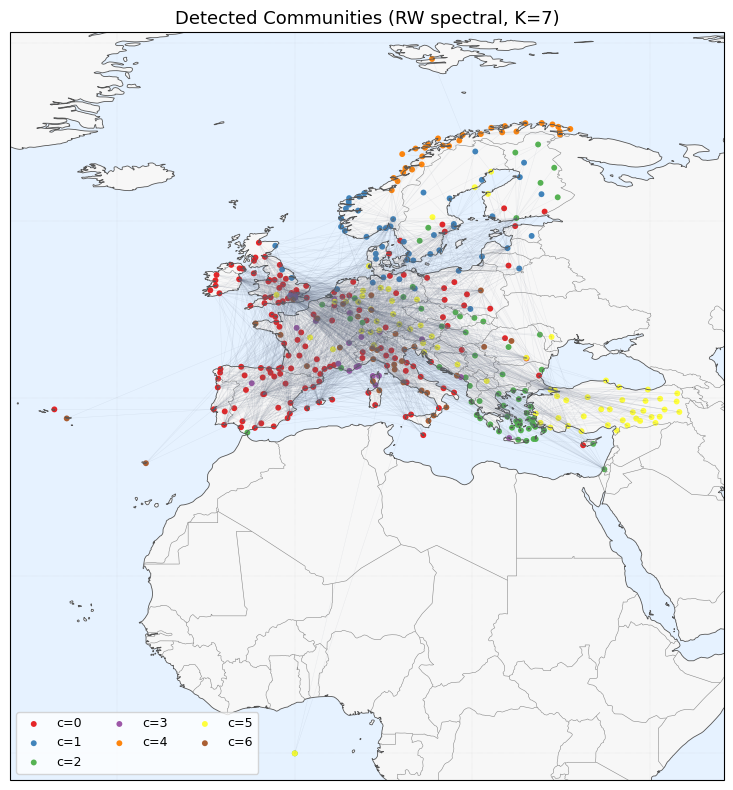

In [11]:
plot_communities_europe_map(
    G,
    community_of,
    node_pos=node_pos,
    title=f"Detected Communities (RW spectral, K={7})",
    node_size=18,
    edge_alpha=0.12,
    draw_edges=True
)

C:\Users\anant\AppData\Local\Temp\ipykernel_1712\2510024013.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


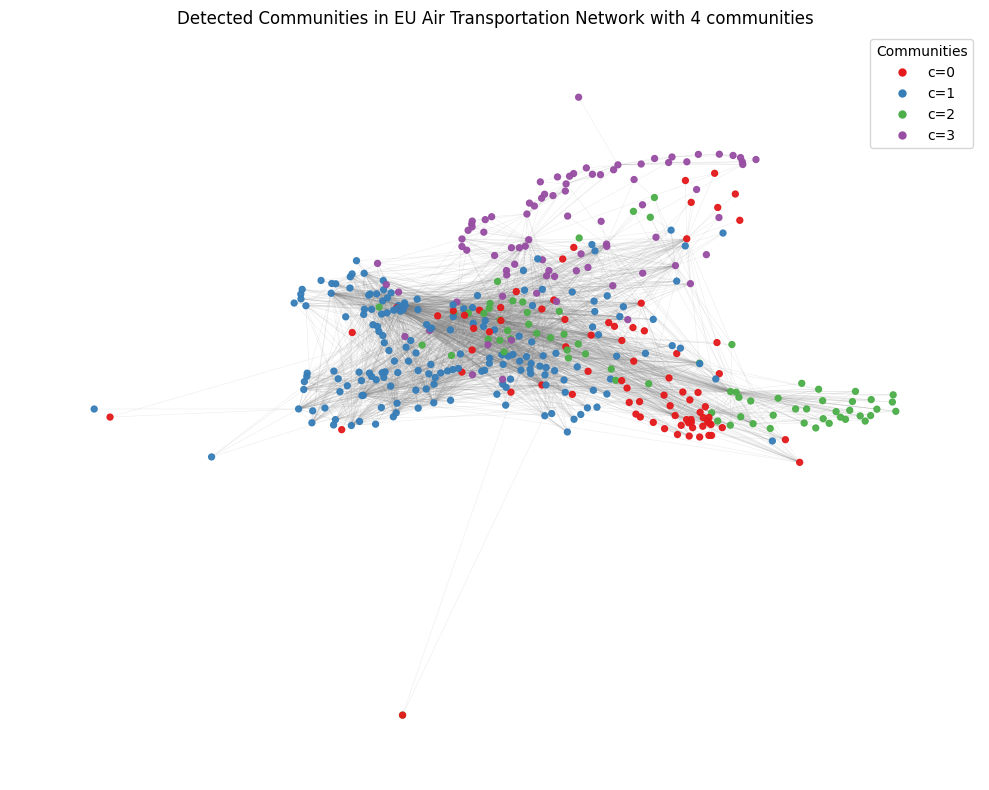

In [12]:

km = KMeans(n_clusters=4, n_init=50, random_state=123)
labels = km.fit_predict(U_norm)
community_of = {nodes[i]: int(labels[i]) for i in range(len(nodes))}
plot_communities(G, community_of, node_pos=node_pos, title=f"Detected Communities in EU Air Transportation Network with {4} communities", show_labels=False)

In [13]:
def lrw_full_spectrum(G, nodes=None, imag_tol=1e-8):
    if nodes is None:
        nodes = list(G.nodes())
    A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight="weight", format="csr")
    deg = np.asarray(A.sum(axis=1)).ravel()
    d_safe = deg.copy(); d_safe[d_safe == 0.0] = 1.0
    Dinv = diags(1.0/d_safe, format="csr")
    L = diags(deg, format="csr") - A
    Lrw = (Dinv @ L).toarray()               

    w, VR = eig(Lrw)                         
    w = np.real(w); VR = np.real(VR)
    w[np.isclose(w, 0.0, atol=imag_tol)] = 0.0  

    order = np.argsort(w)                    
    evals = w[order]
    evecs = VR[:, order]
    num_cc = nx.number_connected_components(G)
    return evals, evecs, nodes, num_cc


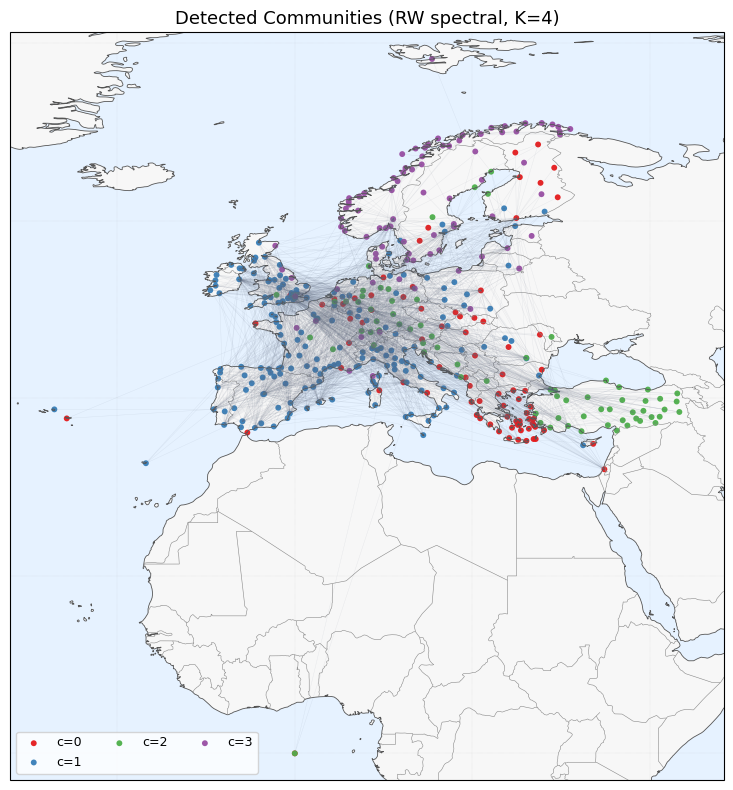

In [14]:
plot_communities_europe_map(
    G,
    community_of,
    node_pos=node_pos,
    title=f"Detected Communities (RW spectral, K={4})",
    node_size=18,
    edge_alpha=0.12,
    draw_edges=True
)


### Histogram distribution

In [15]:
import matplotlib.pyplot as plt
import collections

def load_airline_names(layer_file):
    """
    Read airline layerID -> name mapping from a file like:
        1 Lufthansa
        2 Ryanair
        3 Easyjet
    Returns dict {layerID: name}
    """
    mapping = {}
    with open(layer_file, "r") as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            if len(parts) == 2:
                mapping[parts[0]] = parts[1]
    return mapping

def plot_airline_distribution_per_community(edge_file, layer_file, community_of, K, max_layers=None):
    """
    Make one histogram per community, showing airline distribution.
    - edge_file: multiplex edges (layerID node1 node2 weight)
    - layer_file: mapping of layerID to airline name
    - community_of: dict {node -> community_id}
    - K: number of communities
    - max_layers: optional, cap how many top airlines to show per community
    """
    airline_names = load_airline_names(layer_file)

    comm_airlines = [collections.Counter() for _ in range(K)]
    with open(edge_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            layer, u, v = parts[0], parts[1], parts[2]
            if u in community_of:
                comm_airlines[community_of[u]][layer] += 1
            if v in community_of:
                comm_airlines[community_of[v]][layer] += 1

    for c in range(K):
        counter = comm_airlines[c]
        if not counter:
            print(f"Community {c} has no airlines.")
            continue

        items = counter.most_common(max_layers)
        layer_ids, counts = zip(*items)
        names = [airline_names.get(lid, lid) for lid in layer_ids]

        plt.figure(figsize=(10, 5))
        plt.bar(names, counts, color="#377eb8")
        plt.title(f"Airline distribution in community {c}")
        plt.xlabel("Airline")
        plt.ylabel("Count")
        plt.xticks(rotation=60, ha="right")
        plt.tight_layout()
        plt.show()



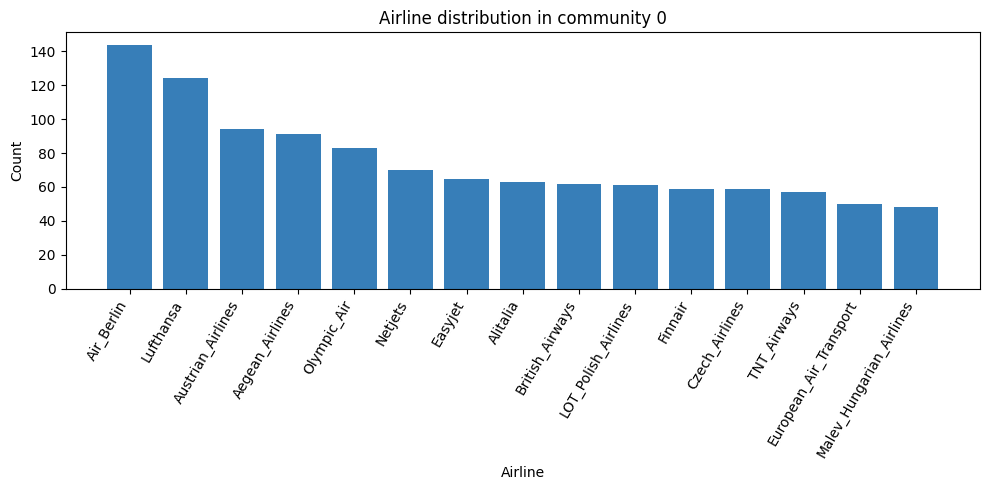

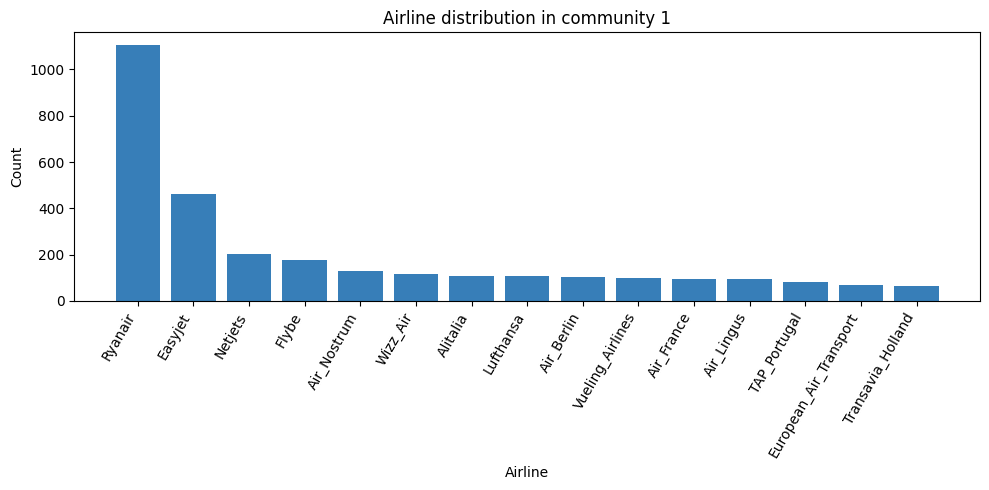

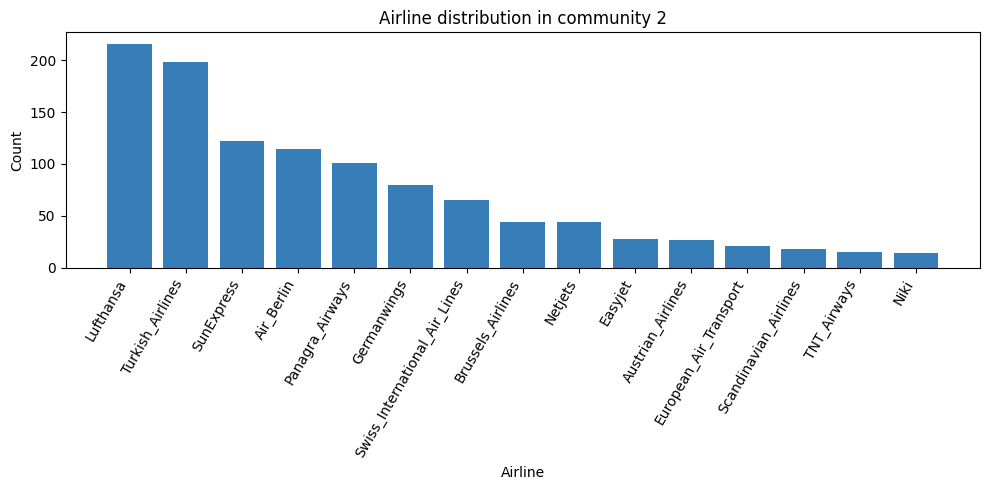

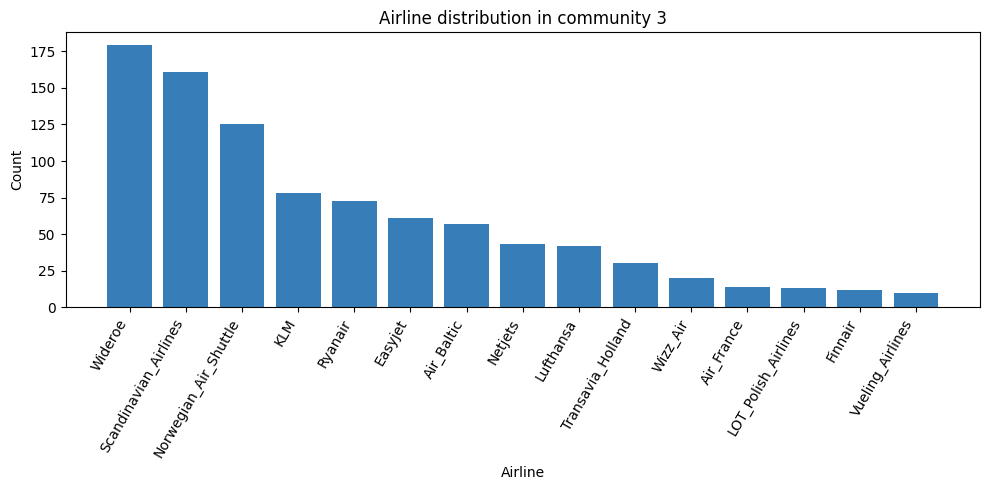

Community 4 has no airlines.
Community 5 has no airlines.
Community 6 has no airlines.


In [16]:
plot_airline_distribution_per_community(
    "../data/EU_air/EUAirTransportation_multiplex.edges",
    "../data/EU_air/EUAirTransportation_layers.txt",
    community_of,
    K=K,
    max_layers=15 
)


In [ ]:
import matplotlib.pyplot as plt
import collections


import pandas as pd


def load_node_to_icao(node_file):
    """
    Parse EUAirTransportation_nodes.txt -> {nodeID: ICAO}
    """
    node_to_icao = {}
    with open(node_file, "r") as f:
        header = next(f)  # skip header if present
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            node_id, icao = parts[0], parts[1]
            node_to_icao[node_id] = icao
    return node_to_icao


def load_icao_to_country(airports_csv="airports.csv"):
    """
    Load OurAirports airports.csv and return {ICAO: country_name}.
    - airports.csv can be downloaded from https://ourairports.com/data/airports.csv
    """
    df = pd.read_csv(airports_csv)

    df = df[df["gps_code"].notna() & (df["gps_code"] != "")]

    mapping = dict(zip(df["gps_code"], df["iso_country"]))
    return mapping


def plot_country_distribution_per_community_from_ourairports(
    community_of, node_file, airports_csv, K,
    normalize=False, top_n=None, sort_desc=True,
    bar_color="#377eb8", title_prefix="Country distribution in community "
):
    node_to_icao = load_node_to_icao(node_file)
    icao_to_country = load_icao_to_country(airports_csv)

    comm_counts = [collections.Counter() for _ in range(K)]
    for node, comm in community_of.items():
        icao = node_to_icao.get(str(node))
        country = icao_to_country.get(icao, "Unknown")
        if 0 <= comm < K:
            comm_counts[comm][country] += 1

    for c in range(K):
        counter = comm_counts[c]
        if not counter:
            print(f"Community {c}: no nodes.")
            continue

        items = counter.items()
        if normalize:
            total = sum(counter.values())
            items = [(k, v / total * 100.0) for k, v in items]

        if sort_desc:
            items = sorted(items, key=lambda kv: kv[1], reverse=True)
        if top_n is not None:
            items = items[:top_n]

        labels, vals = zip(*items)
        plt.figure(figsize=(10, 5))
        plt.bar(labels, vals, color=bar_color)
        ttl = f"{title_prefix}{c}"
        ttl += " (percent)" if normalize else " (count)"
        plt.title(ttl)
        plt.xlabel("Country")
        plt.ylabel("% of airports" if normalize else "Number of airports")
        plt.xticks(rotation=60, ha="right")
        plt.tight_layout()
        plt.show()






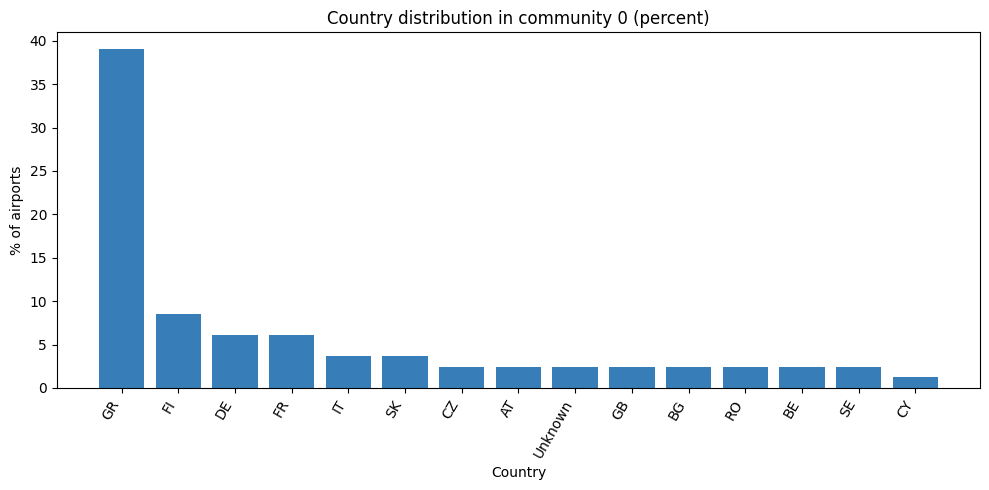

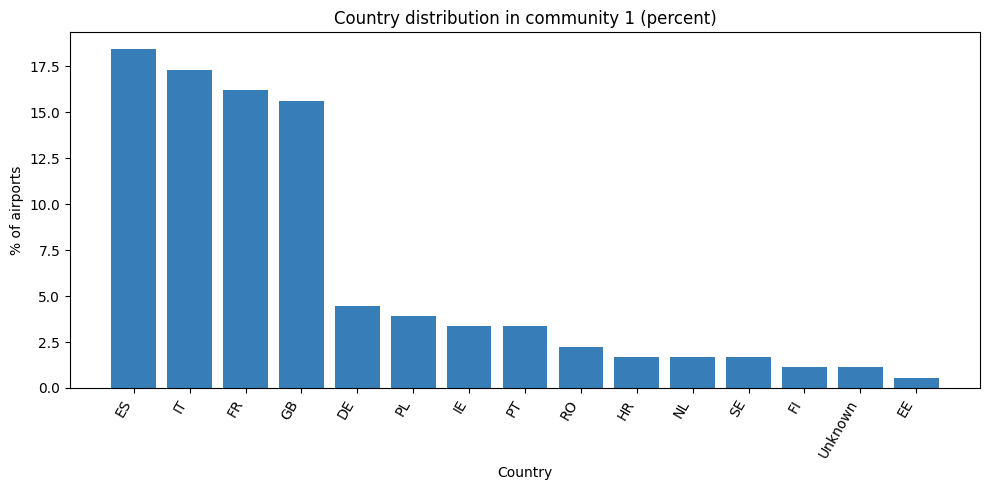

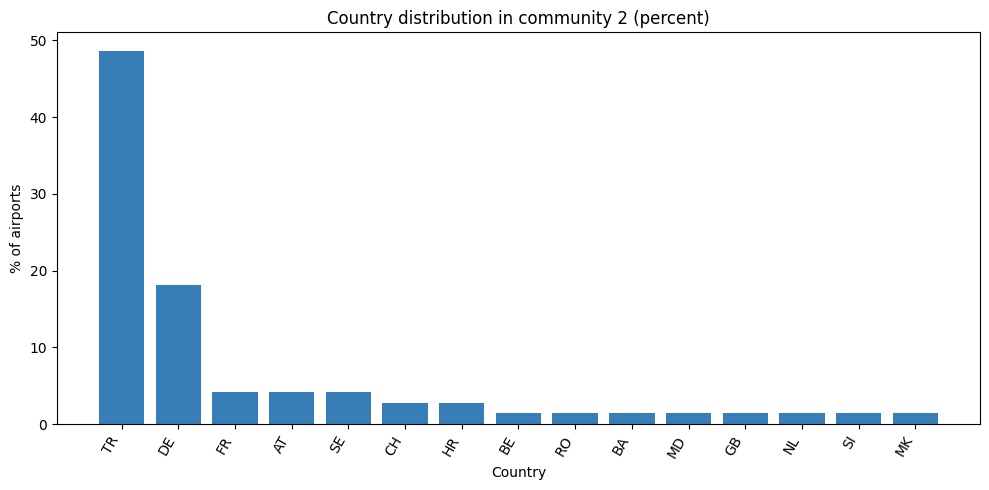

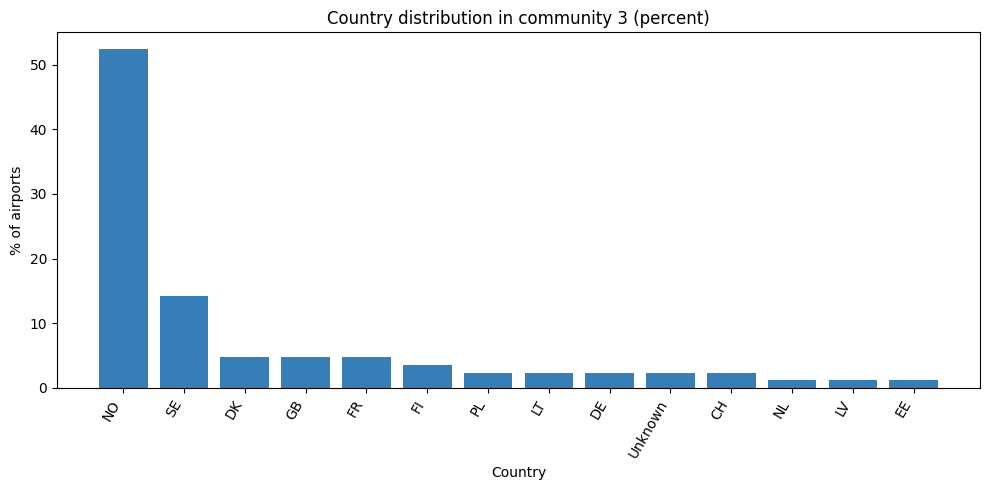

Community 4: no nodes.
Community 5: no nodes.
Community 6: no nodes.


In [18]:
plot_country_distribution_per_community_from_ourairports(
    community_of,
    "../data/EU_Air/EUAirTransportation_nodes.txt",
    "../airports.csv",
    K=K,
    normalize=True,  
    top_n=15         
)




In [19]:
import pandas as pd

def find_unknown_airports(node_file, airports_csv, community_of=None):
    """
    Print airports from node_file whose ICAO code is not found in OurAirports airports.csv.
    Optionally filter to only airports belonging to nodes in community_of.
    """
    node_to_icao = {}
    node_info = {}
    with open(node_file, "r") as f:
        header = next(f)
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            node_id, icao, lon, lat = parts[0], parts[1], parts[2], parts[3]
            node_to_icao[node_id] = icao
            node_info[node_id] = (icao, float(lon), float(lat))

    df = pd.read_csv(airports_csv)
    valid_icaos = set(df["gps_code"].dropna().unique())

    unknowns = {}
    for node_id, icao in node_to_icao.items():
        if icao not in valid_icaos:
            if community_of is None or node_id in community_of:
                unknowns[node_id] = node_info[node_id]

    if not unknowns:
        pass
    else:
        print(f"Found {len(unknowns)} airports with Unknown mapping:\n")
        for node_id, (icao, lon, lat) in unknowns.items():
            comm = community_of.get(node_id, "N/A") if community_of else "N/A"
            print(f"Node {node_id} | ICAO: {icao} | Lon: {lon:.4f}, Lat: {lat:.4f} | Community: {comm}")

    return unknowns


In [20]:
unknowns = find_unknown_airports(
    "../data/EU_air/EUAirTransportation_nodes.txt",
    "../airports.csv",
    community_of=community_of  
)


Found 7 airports with Unknown mapping:

Node 67 | ICAO: EDDT | Lon: 13.2878, Lat: 52.5597 | Community: 0
Node 119 | ICAO: EGCN | Lon: -1.0044, Lat: 53.4747 | Community: 1
Node 259 | ICAO: XXXX | Lon: 0.0000, Lat: 0.0000 | Community: 0
Node 327 | ICAO: ENNK | Lon: 17.3867, Lat: 68.4369 | Community: 3
Node 399 | ICAO: YYYY | Lon: 0.0000, Lat: 0.0000 | Community: 2
Node 409 | ICAO: EGMH | Lon: 1.3461, Lat: 51.3422 | Community: 1
Node 438 | ICAO: EDOP | Lon: 11.7833, Lat: 53.4269 | Community: 3


### Random walk - L matrix, finding better communities.

First 10 eigenvalues: [0.         0.0624397  0.14800049 0.270587   0.31328914 0.35720728
 0.36253765 0.36440655 0.41194773 0.4186762  0.44139725 0.4592476
 0.46067053 0.48538707 0.49435974 0.51246172 0.53500043 0.55159394
 0.55613733 0.57169369]


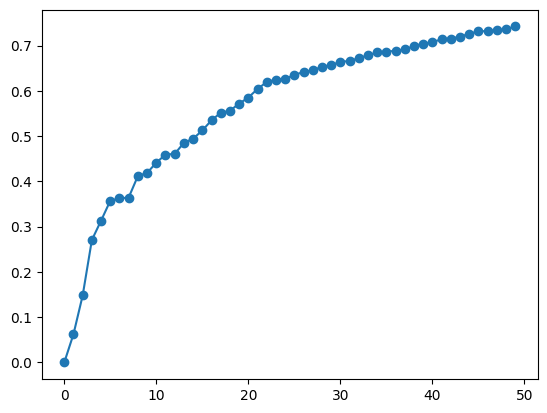

In [21]:
evals_rw, evecs_rw, nodes_rw, num_cc_rw = lrw_full_spectrum(G, nodes=list(G.nodes()))
print("First 10 eigenvalues:", evals_rw[:20])   
plt.plot(evals_rw[:50], marker='o')


In [22]:

def pick_k_from_lrw_eigs(evals, num_cc=0, zero_tol=1e-12, return_debug=False):
    """
    Choose K from L_rw eigenvalues (ascending) via the 'first largest eigengap' rule.
    Args:
      evals     : 1D array-like of eigenvalues of L_rw = D^{-1}L, sorted ascending.
      num_cc    : number of connected components (zeros multiplicity). If unknown,
                  we'll infer it from zero_tol.
      zero_tol  : tolerance to count zeros.
      return_debug : if True, also return dict with gaps and indices.

    Returns:
      K : int (chosen number of communities)
      (optional) debug dict with:
         'start' : index after zero block
         'gaps'  : np.diff(tail)
         'gap_idx': index of chosen gap within the tail
    """
    evals = np.asarray(evals, dtype=float)
    if evals.ndim != 1 or evals.size < 2:
        return 1 if return_debug is False else (1, {"start":0, "gaps":np.array([]), "gap_idx":None})

    if num_cc is None or num_cc <= 0:
        num_cc = int((np.abs(evals) <= zero_tol).sum())

    if num_cc >= len(evals) - 1:
        return max(1, num_cc) if return_debug is False else (max(1, num_cc),
               {"start":num_cc, "gaps":np.array([]), "gap_idx":None})

    tail = evals[num_cc:]              
    gaps = np.diff(tail)               

    if gaps.size == 0:
        return max(1, num_cc) if return_debug is False else (max(1, num_cc),
               {"start":num_cc, "gaps":gaps, "gap_idx":None})

    j = int(np.argmax(gaps))           
    K = num_cc + j + 1                

    if return_debug:
        return int(K), {"start": num_cc, "gaps": gaps, "gap_idx": j}
    return int(K)


In [23]:

K, dbg = pick_k_from_lrw_eigs(evals_rw, num_cc=num_cc, return_debug=True)
print("Connected components:", num_cc)
print("Chosen K (first largest gap):", K)



Connected components: 1
Chosen K (first largest gap): 3


In [24]:
def pick_k_with_dominance(evals, num_cc=0, zero_tol=1e-12, min_ratio=1.25):
    """
    Like pick_k_from_lrw_eigs but requires the chosen gap to be at least
    'min_ratio' times larger than any *previous* gap. If not found, falls back
    to the global maximum (first occurrence). This is taken from the slides.
    """
    K, dbg = pick_k_from_lrw_eigs(evals, num_cc=num_cc, zero_tol=zero_tol, return_debug=True)
    start = dbg["start"]; gaps = dbg["gaps"]; j = dbg["gap_idx"]
    if gaps.size == 0: 
        return K
    if j > 0 and np.max(gaps[:j]) * min_ratio > gaps[j]:
        return K
    return K
print("Chosen K (dominant gap):", pick_k_with_dominance(evals_rw, num_cc=num_cc))

Chosen K (dominant gap): 3


C:\Users\anant\AppData\Local\Temp\ipykernel_1712\2510024013.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


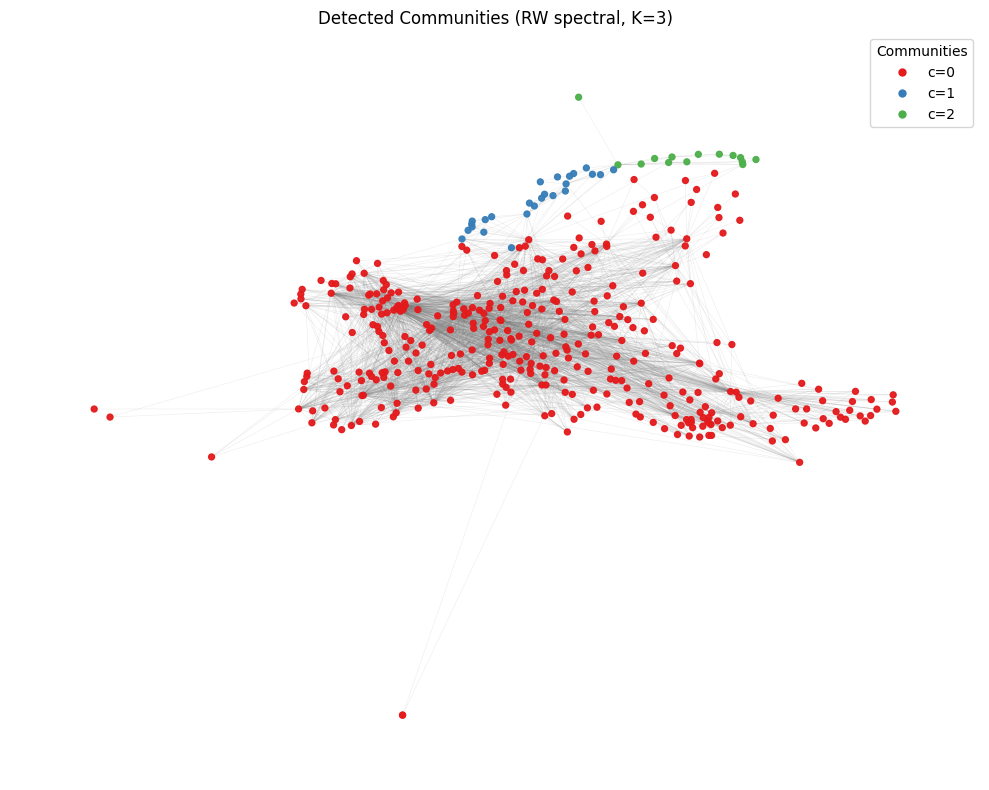

In [25]:
U = evecs_rw[:, :K].astype(float, copy=False)
r = np.linalg.norm(U, axis=1, keepdims=True); r[r == 0.0] = 1.0
U_norm = U / r

km = KMeans(n_clusters=K, n_init=20, random_state=0)
labels = km.fit_predict(U_norm)

community_of = {nodes[i]: int(labels[i]) for i in range(len(nodes))}

plot_communities(
    G,
    community_of,
    node_pos=node_pos,
    title=f"Detected Communities (RW spectral, K={K})",
    show_labels=False
)

C:\Users\anant\AppData\Local\Temp\ipykernel_1712\2510024013.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


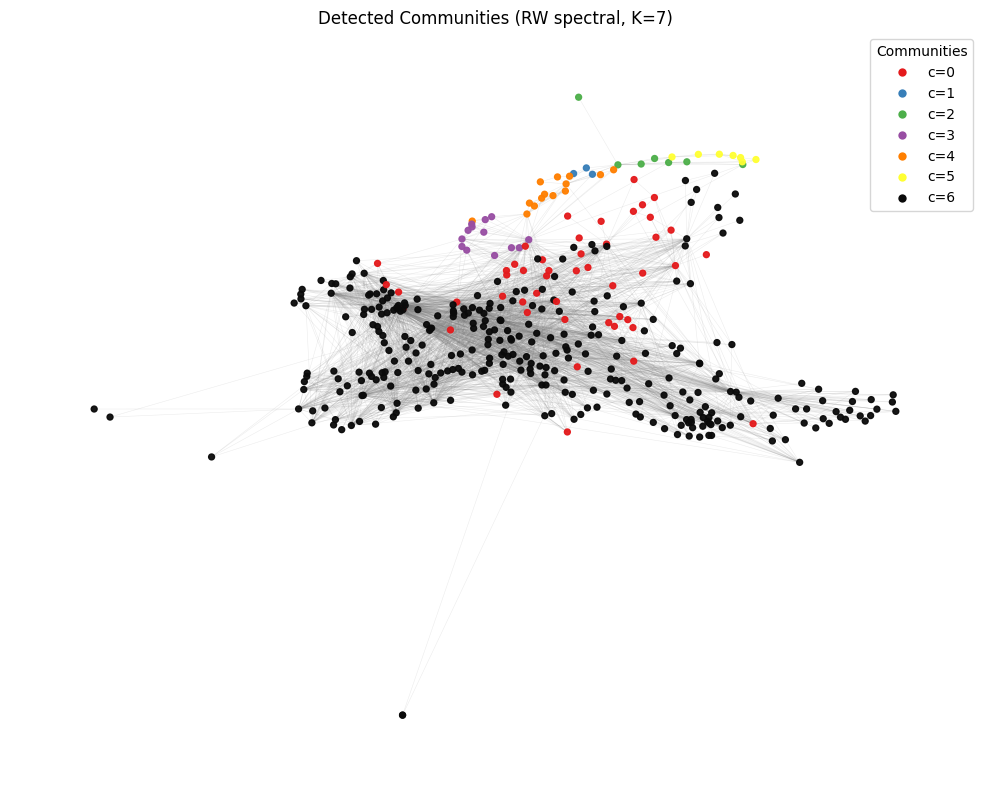

In [26]:
km = KMeans(n_clusters=7, n_init=20, random_state=0)
labels = km.fit_predict(U_norm)

community_of = {nodes[i]: int(labels[i]) for i in range(len(nodes))}

plot_communities(
    G,
    community_of,
    node_pos=node_pos,
    title=f"Detected Communities (RW spectral, K={7})",
    show_labels=False
)

### Different clustering communities - DBSCAN

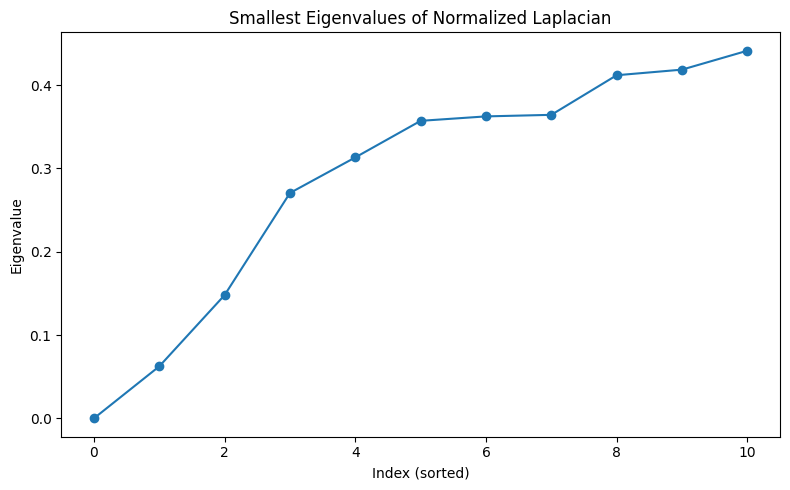

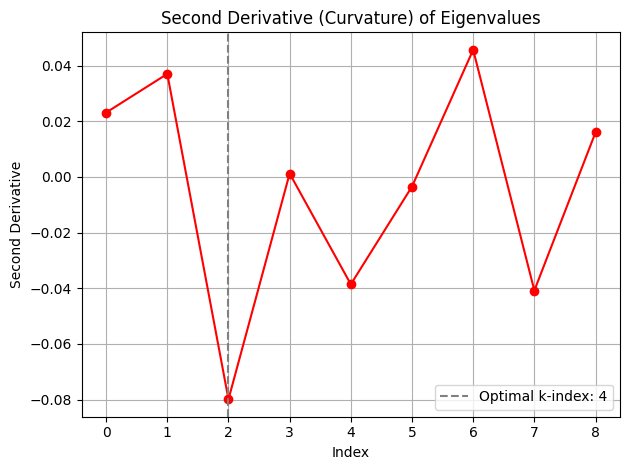


DBSCAN found 11 clusters and 37 noise points.


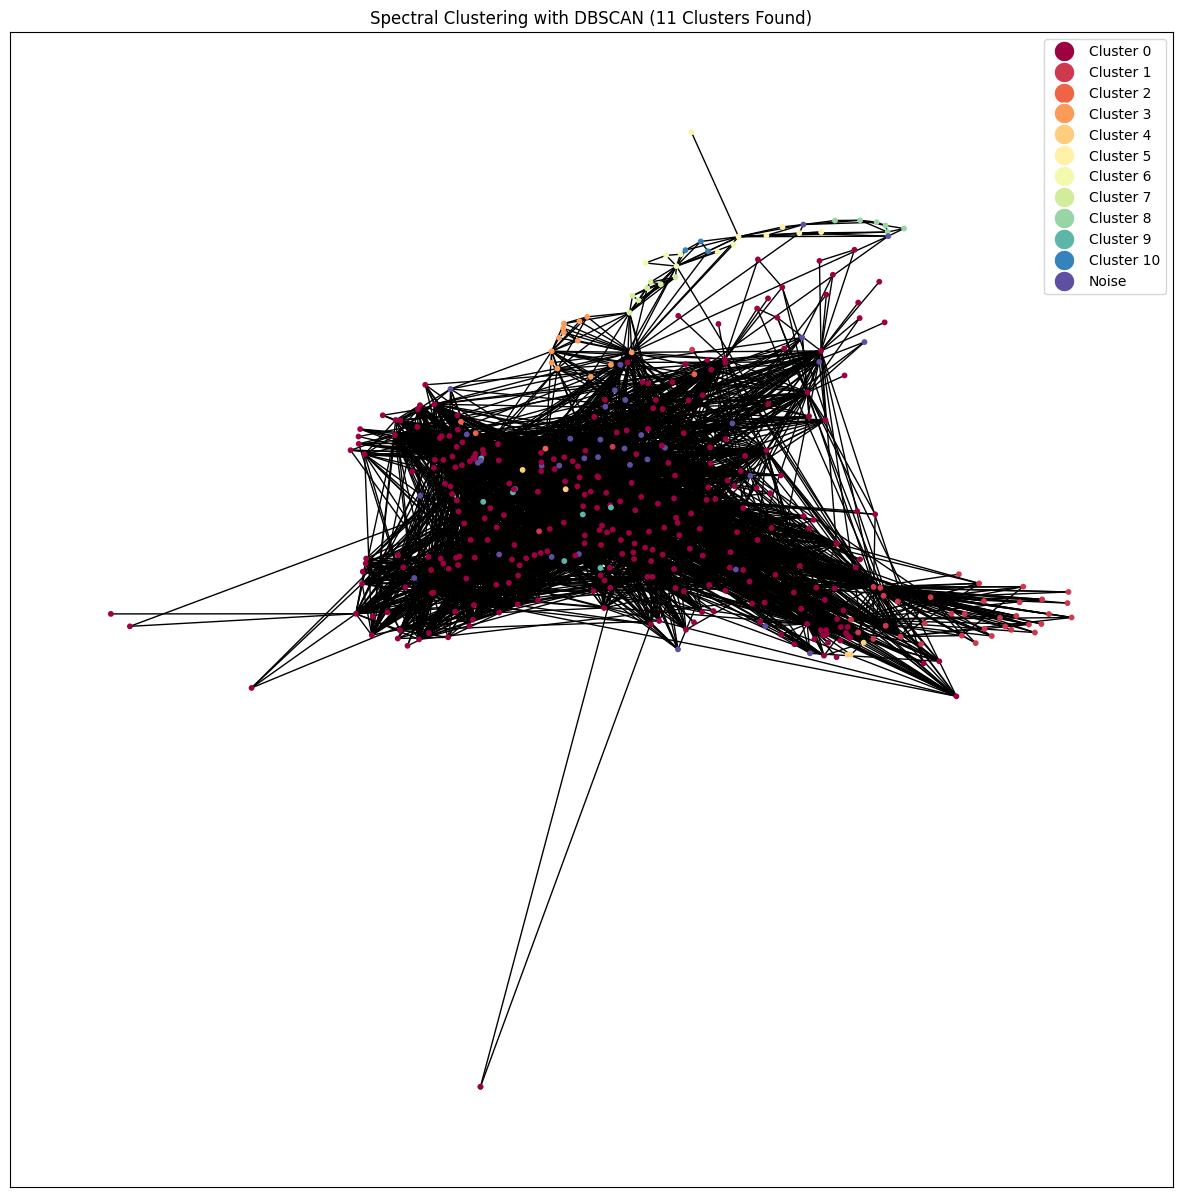

{'1': 0,
 '2': 0,
 '3': 0,
 '4': 0,
 '5': 0,
 '6': 1,
 '7': -1,
 '8': -1,
 '9': 0,
 '10': -1,
 '11': 0,
 '12': 0,
 '13': 1,
 '14': 0,
 '15': 2,
 '16': 1,
 '17': 0,
 '18': 0,
 '19': 0,
 '20': 0,
 '21': 0,
 '22': -1,
 '23': 1,
 '24': 1,
 '25': 1,
 '26': 0,
 '27': 0,
 '28': 0,
 '29': 1,
 '30': -1,
 '31': 3,
 '32': -1,
 '33': -1,
 '34': 0,
 '35': -1,
 '36': 1,
 '37': 0,
 '38': 0,
 '39': 0,
 '40': 0,
 '41': 0,
 '42': 0,
 '43': 0,
 '44': 0,
 '45': 0,
 '46': 0,
 '47': -1,
 '48': 0,
 '49': 0,
 '50': 0,
 '51': 0,
 '52': 0,
 '53': 0,
 '54': 1,
 '55': 0,
 '56': -1,
 '57': 0,
 '58': 0,
 '59': -1,
 '60': 1,
 '61': 0,
 '62': 0,
 '63': 0,
 '64': 0,
 '65': 0,
 '66': 0,
 '67': 0,
 '68': 0,
 '69': 0,
 '70': 0,
 '71': 0,
 '72': 0,
 '73': 1,
 '74': 1,
 '75': 0,
 '76': 0,
 '77': 0,
 '78': 0,
 '79': 0,
 '80': 0,
 '81': 0,
 '82': -1,
 '83': 0,
 '84': 0,
 '85': 4,
 '86': 0,
 '87': 0,
 '88': -1,
 '89': 0,
 '90': 0,
 '91': 0,
 '92': 0,
 '93': 0,
 '94': 1,
 '95': 0,
 '96': 0,
 '97': 5,
 '98': 6,
 '99': 0,
 '100'

In [78]:
import networkx as nx
import numpy as np
from scipy.sparse.linalg import eigs
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

def SpectralClustering_DBSCAN(G, pos, k_max, eps, min_samples):
    # Compute normalized Laplacian
    L = nx.normalized_laplacian_matrix(G, nodelist=list(G.nodes())).astype(np.float64)

    vals, vecs = eigs(L, k=k_max + 1, which='SM')
    
    sorted_indices = np.argsort(vals)
    vals = np.real(vals[sorted_indices])
    vecs = np.real(vecs[:, sorted_indices])
    
    U = vecs[:, 1:k_max + 1]

    row_norms = np.linalg.norm(U, axis=1, keepdims=True)
    row_norms[row_norms == 0.0] = 1.0
    U_norm = U / row_norms
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(len(vals)), vals, marker='o', linestyle='-')
    plt.title('Smallest Eigenvalues of Normalized Laplacian')
    plt.xlabel('Index (sorted)')
    plt.ylabel('Eigenvalue')
    plt.tight_layout()
    plt.show()
    
    second_derivative = np.diff(np.diff(vals))
    plt.plot(range(len(second_derivative)), second_derivative, marker='o', linestyle='-', color='red')
    optimal_k_index = np.argmax(np.abs(second_derivative))
    optimal_k = optimal_k_index + 2 
    plt.axvline(x=optimal_k_index, color='gray', linestyle='--', label=f'Optimal k-index: {optimal_k}')
    plt.title('Second Derivative (Curvature) of Eigenvalues')
    plt.xlabel('Index')
    plt.ylabel('Second Derivative')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(U_norm)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"\nDBSCAN found {n_clusters} clusters and {n_noise} noise points.")
    
    nodes = list(G.nodes())
    community_of = {nodes[i]: int(labels[i]) for i in range(len(nodes))}
    
    unique_labels = set(labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
    label_colors = {label: color for label, color in zip(unique_labels, colors)}
    node_colors = [label_colors[label] for label in labels]
    
    fig, ax = plt.subplots(figsize=(15, 15))
    nx.draw_networkx(G, pos=pos, node_color=node_colors, node_size=10, ax=ax, with_labels=False)
    plt.title(f'Spectral Clustering with DBSCAN ({n_clusters} Clusters Found)')
    
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                   markerfacecolor=label_colors[label], markersize=15)
        for label in unique_labels if label != -1
    ]
    if -1 in unique_labels:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', label='Noise',
                                          markerfacecolor=label_colors[-1], markersize=15))
    
    ax.legend(handles=legend_elements, loc='best')
    plt.show()
    
    return community_of

graph = G.copy()
node_pos = node_pos.copy()

SpectralClustering_DBSCAN(graph, node_pos, k_max=10, eps=0.4, min_samples=3)

## Using Optuna framework for hyper parameter tuning and trying all the clustering ways into 1.

In [ ]:
import networkx as nx
import numpy as np
from scipy.sparse.linalg import eigs
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings('ignore')

def optimize_spectral_clustering(G, algorithm='kmeans', k_max_range=(10, 50), n_trials=100):

    
    print(f"Starting Optuna optimization for spectral clustering with {algorithm}...")
    
    # Pre-compute spectral embedding
    max_k = k_max_range[1]
    L = nx.normalized_laplacian_matrix(G, nodelist=list(G.nodes())).astype(np.float64)
    vals, vecs = eigs(L, k=max_k + 1, which='SM')
    vals = np.real(vals)
    vecs = np.real(vecs)
    sorted_indices = np.argsort(vals)
    vals_sorted = vals[sorted_indices]
    vecs_sorted = vecs[:, sorted_indices]
    
    # Find eigengap suggestion
    eigengaps = np.diff(vals_sorted)
    suggested_k = np.argmax(eigengaps[:min(20, len(eigengaps))]) + 2
    print(f"Eigengap analysis suggests {suggested_k} clusters")
    
    embeddings = {}
    
    def objective(trial):
        k_max = trial.suggest_int('k_max', k_max_range[0], k_max_range[1])
        
        if k_max not in embeddings:
            eigenvector_subset = vecs_sorted[:, 1:k_max + 1]
            
            row_norms = np.linalg.norm(eigenvector_subset, axis=1, keepdims=True)
            row_norms[row_norms == 0.0] = 1.0
            embeddings[k_max] = eigenvector_subset / row_norms
        
        embedding_scaled = embeddings[k_max]
        
        if algorithm == 'kmeans':
            n_clusters = trial.suggest_int('n_clusters', 3, min(25, len(embedding_scaled)//10))
            clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)  # More inits
            labels = clusterer.fit_predict(embedding_scaled)
            n_noise = 0
            
        elif algorithm == 'hierarchical':
            n_clusters = trial.suggest_int('n_clusters', 3, min(25, len(embedding_scaled)//10))
            linkage = trial.suggest_categorical('linkage', ['ward', 'complete', 'average'])
            clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
            labels = clusterer.fit_predict(embedding_scaled)
            n_noise = 0
            
        elif algorithm == 'dbscan':
            # For DBSCAN, we might still need some standardization after row normalization
            # because DBSCAN is distance-based
            # scaler = StandardScaler()
            # embedding_standardized = scaler.fit_transform(embedding_scaled)
            
            
            eps = trial.suggest_float('eps', 0.001, 0.5, log=True)
            min_samples = trial.suggest_int('min_samples', 2, 8)
            
            # Use fewer dimensions for DBSCAN
            k_max_dbscan = min(k_max, 20)
            # embedding_dbscan = embedding_standardized[:, :k_max_dbscan]
            embedding_dbscan = embedding_scaled[:, :k_max_dbscan]
            clusterer = DBSCAN(eps=eps, min_samples=min_samples)
            labels = clusterer.fit_predict(embedding_dbscan)
            # labels = clusterer.fit_predict(embedding_dbscan)
            
            n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            # Strict pruning for DBSCAN
            if n_clusters_found < 2 or n_noise > 0.4 * len(labels):
                return float('inf')
                
            embedding_scaled = embedding_dbscan  # Use reduced dimensions for scoring
        
        # Calculate scores
        n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters_found < 2:
            return float('inf')
        
        try:
            sil_score = silhouette_score(embedding_scaled, labels)
            ch_score = calinski_harabasz_score(embedding_scaled, labels)
            
            # Combined score (negate for minimization)
            combined_score = -(0.6 * sil_score + 0.4 * (ch_score / 1000))
            
            # Add penalty for noise (only for DBSCAN)
            if algorithm == 'dbscan' and n_noise > 0:
                noise_penalty = (n_noise / len(labels)) * 0.2
                combined_score += noise_penalty
            
            return combined_score
            
        except ValueError:
            return float('inf')
    
    # Optimize
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    best_params = study.best_params
    best_score = study.best_value
    
    print("\n" + "="*60)
    print(f"OPTUNA OPTIMIZATION RESULTS - {algorithm.upper()}")
    print("="*60)
    print(f"Best Score: {-best_score:.4f}")
    print(f"Best Parameters:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")
    
    return best_params, study


def SpectralClustering_MultiAlgorithm(G, pos, algorithm='kmeans', **params):
    """
    Performs spectral clustering with multiple algorithm options.
    """
    
    print("Computing normalized Laplacian matrix...")
    L = nx.normalized_laplacian_matrix(G, nodelist=list(G.nodes())).astype(np.float64)
    
    k_max = params.get('k_max', 20)
    print(f"Computing {k_max + 1} smallest eigenvalues and eigenvectors...")
    vals, vecs = eigs(L, k=k_max + 1, which='SM')
    
    # Process eigenvalues/vectors
    vals = np.real(vals)
    vecs = np.real(vecs)
    sorted_indices = np.argsort(vals)
    vals = vals[sorted_indices]
    vecs = vecs[:, sorted_indices]
    
    # Create spectral embedding (skip first trivial eigenvector)
    eigenvector_subset = vecs[:, 1:k_max + 1]  # Skip first eigenvector
    print(f"Created spectral embedding: {eigenvector_subset.shape}")
    
    # CRITICAL: Normalize each row (node) to unit length
    # This is essential for proper spectral clustering!
    row_norms = np.linalg.norm(eigenvector_subset, axis=1, keepdims=True)
    row_norms[row_norms == 0.0] = 1.0  # Avoid division by zero
    eigenvector_normalized = eigenvector_subset / row_norms
    
    print("Applied row-wise normalization (essential for spectral clustering)")
    
    # Note: We DON'T use StandardScaler after row normalization
    # StandardScaler would undo the important geometric properties
    eigenvector_scaled = eigenvector_normalized
    
    # Choose clustering algorithm
    if algorithm == 'kmeans':
        n_clusters = params.get('n_clusters', 8)
        print(f"Running KMeans with {n_clusters} clusters...")
        clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        labels = clusterer.fit_predict(eigenvector_scaled)
        n_noise = 0
        
    elif algorithm == 'hierarchical':
        n_clusters = params.get('n_clusters', 8)
        linkage = params.get('linkage', 'ward')
        print(f"Running Hierarchical clustering with {n_clusters} clusters, {linkage} linkage...")
        clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        labels = clusterer.fit_predict(eigenvector_scaled)
        n_noise = 0
        
    elif algorithm == 'dbscan':
        # For DBSCAN, apply additional standardization after row normalization
        scaler = StandardScaler()
        # embedding_standardized = scaler.fit_transform(eigenvector_scaled)
        
        eps = params.get('eps', 0.1)
        min_samples = params.get('min_samples', 3)
        
        # Use fewer dimensions for DBSCAN
        k_max_dbscan = min(k_max, 15)
        embedding_dbscan = eigenvector_scaled[:, :k_max_dbscan]
        
        print(f"Running DBSCAN with eps={eps}, min_samples={min_samples}, {k_max_dbscan} dimensions...")
        clusterer = DBSCAN(eps=eps, min_samples=min_samples)
        labels = clusterer.fit_predict(embedding_dbscan)
        n_noise = list(labels).count(-1)
        
        
        
    
    # Results
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    print(f"\n{algorithm.upper()} Results:")
    print(f"  Clusters found: {n_clusters}")
    print(f"  Noise points: {n_noise}")
    print(f"  Clustered points: {len(labels) - n_noise}")
    
    if n_clusters > 0:
        cluster_sizes = [list(labels).count(i) for i in range(n_clusters)]
        print(f"  Cluster sizes: {cluster_sizes}")
    
    # Calculate quality metrics
    if n_clusters >= 2:
        try:
            embedding_for_metrics = embedding_dbscan if algorithm == 'dbscan' else eigenvector_scaled
            sil_score = silhouette_score(embedding_for_metrics, labels)
            ch_score = calinski_harabasz_score(embedding_for_metrics, labels)
            print(f"  Silhouette Score: {sil_score:.4f}")
            print(f"  Calinski-Harabasz Score: {ch_score:.4f}")
        except:
            pass
    
    # Print detailed cluster information
    print(f"\nDetailed Cluster Information:")
    print(f"{'Cluster':<10} {'Size':<10} {'Percentage':<12}")
    print("-" * 32)
    
    total_nodes = len(labels)
    for cluster_id in sorted(set(labels)):
        cluster_size = list(labels).count(cluster_id)
        percentage = (cluster_size / total_nodes) * 100
        
        if cluster_id == -1:
            print(f"{'Noise':<10} {cluster_size:<10} {percentage:<12.1f}%")
        else:
            print(f"{cluster_id:<10} {cluster_size:<10} {percentage:<12.1f}%")
    
    # Visualize with better colors and no edges
    unique_labels = set(labels)
    n_unique = len(unique_labels)
    
    # Use better color schemes based on number of clusters
    if n_unique <= 10:
        colors = plt.cm.Set3(np.linspace(0, 1, n_unique))
    elif n_unique <= 20:
        colors = plt.cm.tab20(np.linspace(0, 1, n_unique))
    else:
        colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_unique))
    
    label_colors = {}
    color_idx = 0
    for label in sorted(unique_labels):
        if label == -1:
            label_colors[label] = [0.8, 0.8, 0.8, 1.0]  # Light gray for noise
        else:
            label_colors[label] = colors[color_idx]
            color_idx += 1
    
    node_colors = [label_colors[label] for label in labels]
    
    plt.figure(figsize=(16, 12))
    # Remove edges and make nodes larger and more visible
    nx.draw_networkx_nodes(G, pos=pos, node_color=node_colors, node_size=60, alpha=0.9)
    # Draw edges very lightly if you want to keep some structure visible
    nx.draw_networkx_edges(G, pos=pos, alpha=0.1, width=0.3, edge_color='lightgray')
    
    plt.title(f'Spectral Clustering with {algorithm.upper()}\n{n_clusters} Clusters, {n_noise} Noise Points', 
              fontsize=16, pad=20)
    
    # Create enhanced legend with cluster sizes
    legend_elements = []
    for label in sorted(unique_labels):
        cluster_size = list(labels).count(label)
        if label != -1:
            legend_elements.append(
                plt.Line2D([0], [0], marker='o', color='w', 
                          label=f'Cluster {label} ({cluster_size} nodes)',
                          markerfacecolor=label_colors[label], markersize=12)
            )
    if -1 in unique_labels:
        noise_size = list(labels).count(-1)
        legend_elements.append(
            plt.Line2D([0], [0], marker='o', color='w', 
                      label=f'Noise ({noise_size} nodes)',
                      markerfacecolor=label_colors[-1], markersize=12)
        )
    
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), 
               fontsize=10, frameon=True, fancybox=True, shadow=True)
    plt.axis('off')  # Remove axis for cleaner look
    plt.tight_layout()
    plt.show()
    
    return labels, n_clusters, n_noise


# Example usage - Compare different algorithms
graph = G.copy()
node_pos = node_pos.copy()

print("=== COMPARING SPECTRAL CLUSTERING ALGORITHMS ===")

algorithms_to_test = ['kmeans', 'hierarchical', 'dbscan']
results = {}

for algo in algorithms_to_test:
    print(f"\n{'='*60}")
    print(f"TESTING {algo.upper()}")
    print(f"{'='*60}")
    
    # Optimize parameters
    if algo == 'dbscan':
        best_params, study = optimize_spectral_clustering(
            graph, algorithm=algo, k_max_range=(10, 20), n_trials=100
        )
    else:
        best_params, study = optimize_spectral_clustering(
            graph, algorithm=algo, k_max_range=(15, 40), n_trials=100
        )
    
    # Run with best parameters
    print(f"\nRunning {algo} with optimized parameters...")
    labels, n_clusters, n_noise = SpectralClustering_MultiAlgorithm(
        graph, node_pos, algorithm=algo, **best_params
    )
    
    results[algo] = {
        'labels': labels,
        'n_clusters': n_clusters, 
        'n_noise': n_noise,
        'params': best_params
    }

# Summary comparison
print(f"\n{'='*60}")
print("FINAL COMPARISON")
print(f"{'='*60}")

for algo, result in results.items():
    noise_pct = result['n_noise'] / len(result['labels']) * 100
    print(f"{algo.upper():>12}: {result['n_clusters']} clusters, "
          f"{result['n_noise']} noise ({noise_pct:.1f}%)")

# Recommend best approach
best_algo = min(results.keys(), 
                key=lambda x: results[x]['n_noise'] / len(results[x]['labels']))
print(f"\nRECOMMENDATION: Use {best_algo.upper()} - lowest noise ratio")

[I 2025-09-22 09:41:19,940] A new study created in memory with name: no-name-02001a32-80e6-43e7-8f39-8607d2d16073
[I 2025-09-22 09:41:20,100] Trial 0 finished with value: -0.058101842099136505 and parameters: {'k_max': 32, 'n_clusters': 3}. Best is trial 0 with value: -0.058101842099136505.


=== COMPARING SPECTRAL CLUSTERING ALGORITHMS ===

TESTING KMEANS
Starting Optuna optimization for spectral clustering with kmeans...
Eigengap analysis suggests 4 clusters


[I 2025-09-22 09:41:20,262] Trial 1 finished with value: -0.220932688081155 and parameters: {'k_max': 16, 'n_clusters': 5}. Best is trial 1 with value: -0.220932688081155.
[I 2025-09-22 09:41:20,446] Trial 2 finished with value: -0.07451062380355888 and parameters: {'k_max': 40, 'n_clusters': 5}. Best is trial 1 with value: -0.220932688081155.
[I 2025-09-22 09:41:20,668] Trial 3 finished with value: -0.17100389853458542 and parameters: {'k_max': 36, 'n_clusters': 24}. Best is trial 1 with value: -0.220932688081155.
[I 2025-09-22 09:41:20,833] Trial 4 finished with value: -0.2144765415200661 and parameters: {'k_max': 25, 'n_clusters': 23}. Best is trial 1 with value: -0.220932688081155.
[I 2025-09-22 09:41:20,971] Trial 5 finished with value: -0.10639706520341193 and parameters: {'k_max': 36, 'n_clusters': 9}. Best is trial 1 with value: -0.220932688081155.
[I 2025-09-22 09:41:21,092] Trial 6 finished with value: -0.05049768762642709 and parameters: {'k_max': 35, 'n_clusters': 3}. Best 